### EDA and preprocessing 

In [1]:
import pandas as pd

data     = pd.read_excel('data/data.xlsx')
btct_ref = pd.read_excel('data/btct_ref.xlsx')
bta_ref  = pd.read_excel('data/bta_ref.xlsx')

In [2]:
data.head()

,ISIN,Libellé,Maturité Résiduelle,Duration Modifiée,YTM,Prix Pied Coupon,Prix Plein Coupon
0,TN9FK1JVMO04,BTCT 52 semaines 04052026,"0,0465753424658","0,0435149654563","0,0703292988363","0,9968394487351","0,9968394487351"
1,TNPKPPDE1295,BTCT 52 semaines 05052026,"0,0493150684932","0,0460730458638","0,070367013263","0,9966521135094","0,9966521135094"
2,TN0HHORW0CG7,BTCT 52 semaines 19052026,"0,0876712328767","0,0818678474919","0,0708872354978","0,9940136069913","0,9940136069913"
3,TN75MC7A2819,BTCT 52 semaines 08062026,"0,1424657534247","0,132946048546","0,0716057752958","0,9901956967343","0,9901956967343"
4,TN0008000820,EMP NATI T1 2021 CA,"0,2054794520548","0,1916075357265","0,0723975509403","1,0023763984567","1,071499686128"


In [3]:
data = data.rename(columns={
    'Libellé'            : 'lib',
    'Maturité Résiduelle': 'residual_maturity',
    'Duration Modifiée'  : 'modified_duration',
    'Prix Pied Coupon'   : 'clean_price',
    'Prix Plein Coupon'  : 'dirty_price'
})

In [4]:
for col in ['residual_maturity', 'modified_duration', 'YTM', 'clean_price', 'dirty_price']:
    data[col] = data[col].astype(str).str.replace(',', '.', regex=False).astype(float)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ISIN               143 non-null    object 
 1   lib                143 non-null    object 
 2   residual_maturity  143 non-null    float64
 3   modified_duration  143 non-null    float64
 4   YTM                143 non-null    float64
 5   clean_price        143 non-null    float64
 6   dirty_price        143 non-null    float64
dtypes: float64(5), object(2)
memory usage: 7.9+ KB


In [6]:
bta_ref.head()

,#,Code ISIN,Libelle,Durée Restante,Nominal (DT),Encours (DT),Dernière échéance,Taux d'intérêt brut
0,1,TN0008000580,"BTA 6,3% Octobre 2026",NaN,1000.0,817500000,14/10/2026,"6,30%"
1,2,TN0008000606,"BTA 6,7% Avril 2028",NaN,1000.0,833687000,13/04/2028,6.7%
2,3,TN0008000655,"BTA 6,6% Mars 2027",NaN,1000.0,540650000,29/03/2027,6.6%
3,4,TN0008000663,"BTA 7,5% Juillet 2032",NaN,1000.0,954890000,15/07/2032,7.50%
4,5,TN0008000697,BTA 7% juillet 2028,NaN,1000.0,237300000,10/07/2028,7%


In [7]:
btct_ref.head()

,#,Code ISIN,Libelle,Durée Restante,Nominal (DT),Encours (DT),Dernière échéance
0,1,TN6IDKUUW874,BTCT 52 semaines 10042026,NaN,NaN,100000000,10/04/2026
1,2,TN9FK1JVMO04,BTCT 52 semaines 04052026,NaN,NaN,96000000,04/05/2026
2,3,TNPKPPDE1295,BTCT 52 semaines 05052026,NaN,NaN,110000000,05/05/2026
3,4,TN0HHORW0CG7,BTCT 52 semaines 19052026,NaN,NaN,98700000,19/05/2026
4,5,TN75MC7A2819,BTCT 52 semaines 08062026,NaN,NaN,183900000,08/06/2026


In [8]:
btct_ref = btct_ref.rename(columns={'Code ISIN': 'ISIN'})
bta_ref  = bta_ref.rename(columns={'Code ISIN': 'ISIN'})

In [9]:
btct_ref['maturity_date'] = pd.to_datetime(btct_ref['Dernière échéance'], dayfirst=True)
bta_ref['maturity_date']  = pd.to_datetime(bta_ref['Dernière échéance'],  dayfirst=True)

In [10]:
bta_ref['coupon_rate'] = (
    bta_ref["Taux d'intérêt brut"]
    .str.replace('%', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float) / 100
)

In [11]:
btct_daily = data[data['lib'].str.contains('BTC', na=False)].copy()
bta_daily  = data[data['lib'].str.contains('BTA', na=False)].copy()

btct = btct_daily.merge(btct_ref[['ISIN', 'maturity_date']], on='ISIN', how='left')
bta  = bta_daily.merge(bta_ref[['ISIN', 'coupon_rate', 'maturity_date']], on='ISIN', how='left')

In [12]:
bta.head()

,ISIN,lib,residual_maturity,modified_duration,YTM,clean_price,dirty_price,coupon_rate,maturity_date
0,TN0008000580,"BTA 6,3% Octobre2026",0.493151,0.458495,0.075585,0.993550,1.025481,0.063,2026-10-14
1,TN0008000721,"BTA 7,2% Février2027",0.821918,0.762098,0.078494,0.994623,1.007445,0.072,2027-02-11
2,TN0008000655,"BTA 6,6% 03/2027",0.947945,0.878186,0.079436,0.988067,0.991322,0.066,2027-03-29
3,TN0008000747,"BTA 7,2% Mai 2027",1.071233,0.929051,0.080230,0.991675,1.058547,0.072,2027-05-13
4,TN9EGII9CQ82,"BTA 9,70% 14 octobre 2027",1.493151,1.298761,0.082416,1.018775,1.067939,0.097,2027-10-14


In [13]:
btct.head()

,ISIN,lib,residual_maturity,modified_duration,YTM,clean_price,dirty_price,maturity_date
0,TN9FK1JVMO04,BTCT 52 semaines 04052026,0.046575,0.043515,0.070329,0.996839,0.996839,2026-05-04
1,TNPKPPDE1295,BTCT 52 semaines 05052026,0.049315,0.046073,0.070367,0.996652,0.996652,2026-05-05
2,TN0HHORW0CG7,BTCT 52 semaines 19052026,0.087671,0.081868,0.070887,0.994014,0.994014,2026-05-19
3,TN75MC7A2819,BTCT 52 semaines 08062026,0.142466,0.132946,0.071606,0.990196,0.990196,2026-06-08
4,TN5I4F50XVD0,BTCT 52 semaines 17072026,0.249315,0.232369,0.072927,0.982604,0.982604,2026-07-17


In [14]:
valuation_date = pd.Timestamp('2026-04-17')
btct['T'] = (btct['maturity_date'] - valuation_date).dt.days / 365.0
bta['T']  = (bta['maturity_date']  - valuation_date).dt.days / 365.0

In [15]:
btct = btct[btct['T'] > 0].dropna(subset=['T', 'YTM']).sort_values('T').reset_index(drop=True)
bta  = bta[bta['T']  > 0].dropna(subset=['T', 'YTM', 'coupon_rate']).sort_values('T').reset_index(drop=True)

In [16]:
print(f"BTCT: {len(btct)} instruments, maturity range: {btct['T'].min():.2f} - {btct['T'].max():.2f} years")
print(f"BTA:  {len(bta)} instruments, maturity range: {bta['T'].min():.2f} - {bta['T'].max():.2f} years")

BTCT: 14 instruments, maturity range: 0.05 - 0.91 years
BTA:  40 instruments, maturity range: 0.49 - 11.89 years


### Bootstrap and Log-linear interpolation

In [17]:
import numpy as np


discount_factors = {}
zc_maturities    = []
zc_rates         = []

for _, row in btct.iterrows():
    T   = row['T']
    ytm = row['YTM']
    df_val = 1 / (1 + ytm) ** T
    discount_factors[T] = df_val
    zc_maturities.append(T)
    zc_rates.append(np.log(1 + ytm))

In [18]:
[float(x) for x in zc_rates]

[0.06796635704845082,
 0.06800159271124971,
 0.06848749693802385,
 0.0691582480875675,
 0.07039076921307647,
 0.07210690321856328,
 0.0728391308794664,
 0.07393218242972789,
 0.07418452488005135,
 0.07486605748862382,
 0.07550594007682528,
 0.07572346001231506,
 0.07585936509655286,
 0.07620005983115788]

In [19]:
def interp_loglinear(t, discount_factors):
    known_T  = [0] + sorted(discount_factors.keys())
    known_DF = [1.0] + [discount_factors[k] for k in sorted(discount_factors.keys())]
    log_DF   = np.log(known_DF)
    return np.exp(np.interp(t, known_T, log_DF))

In [20]:
for _, row in bta.iterrows():
    T      = row['T']
    coupon = row['coupon_rate']
    price  = row['dirty_price']
    ytm    = row['YTM']

    n_coupons    = int(np.ceil(T))
    coupon_times = [T - i for i in range(n_coupons - 1, -1, -1)]
    coupon_times = [t for t in coupon_times if t > 0]

    pv_intermediate = sum(
        coupon * interp_loglinear(t, discount_factors)
        for t in coupon_times[:-1]
    )

    df_T = (price - pv_intermediate) / (1 + coupon)

    prev_T  = max((t for t in discount_factors if t < T), default=None)
    prev_DF = discount_factors[prev_T] if prev_T else 1.0

    if df_T <= 0 or df_T >= prev_DF:
        df_T = 1 / (1 + ytm) ** T

    zc_rate_T = -np.log(df_T) / T
    discount_factors[T] = df_T
    zc_maturities.append(T)
    zc_rates.append(zc_rate_T)

In [21]:
zc_maturities = np.array(zc_maturities)
zc_rates      = np.array(zc_rates)
sort_idx      = np.argsort(zc_maturities)
zc_maturities = zc_maturities[sort_idx]
zc_rates      = zc_rates[sort_idx]

print(f"\nTotal bootstrapped ZC points: {len(zc_maturities)}")


Total bootstrapped ZC points: 54


### Nelson-Siegel fit

In [22]:
def ns_curve(tau, beta0, beta1, beta2, lam):
    tau = np.maximum(tau, 1e-10)
    f2  = (1 - np.exp(-lam * tau)) / (lam * tau)
    f3  = f2 - np.exp(-lam * tau)
    return beta0 + beta1 * f2 + beta2 * f3

In [23]:
def ns_objective(params, taus, rates):
    b0, b1, b2, lam = params
    if lam <= 0: return 1e10
    return np.sum((ns_curve(taus, b0, b1, b2, lam) - rates) ** 2)

In [24]:
from scipy.optimize import minimize

BOUNDS = [(0.01, 0.20), (-0.15, 0.15), (-0.15, 0.15), (0.1, 3.0)]
X0     = [0.08, -0.03, -0.01, 0.7]

# First pass : outlier detection
res_prelim   = minimize(ns_objective, X0, args=(zc_maturities, zc_rates),
                        method='SLSQP', bounds=BOUNDS)
residuals    = zc_rates - ns_curve(zc_maturities, *res_prelim.x)
outlier_mask = np.abs(residuals) > 2 * np.std(residuals)

zc_mat_clean   = zc_maturities[~outlier_mask]
zc_rates_clean = zc_rates[~outlier_mask]

# Final fit
res_final = minimize(ns_objective, X0, args=(zc_mat_clean, zc_rates_clean),
                     method='L-BFGS-B', bounds=BOUNDS)
beta0, beta1, beta2, lam = res_final.x

In [25]:
# Tunisie Clearing Benchmark

TC_BETA0  =  0.084459
TC_BETA1  = -0.017103
TC_BETA2  =  0.020044
TC_LAMBDA =  0.71732

clean_fitted = ns_curve(zc_mat_clean, beta0, beta1, beta2, lam)
rmse_fitted  = np.sqrt(np.mean((clean_fitted - zc_rates_clean) ** 2)) * 100

tc_at_clean  = ns_curve(zc_mat_clean, TC_BETA0, TC_BETA1, TC_BETA2, TC_LAMBDA)
rmse_tc      = np.sqrt(np.mean((tc_at_clean - zc_rates_clean) ** 2)) * 100

In [26]:
print(f"\nNS Parameters:")
print(f"  β0 = {beta0:.6f}  β1 = {beta1:.6f}  β2 = {beta2:.6f}  λ = {lam:.6f}")
print(f"\n  Fitted RMSE : {rmse_fitted:.4f} bps")
print(f"  TC RMSE   : {rmse_tc:.4f} bps")
print(f"  Outliers  : {outlier_mask.sum()} of {len(zc_maturities)}")


NS Parameters:
  β0 = 0.083918  β1 = -0.016518  β2 = 0.021123  λ = 0.702029

  Fitted RMSE : 0.0191 bps
  TC RMSE   : 0.0238 bps
  Outliers  : 3 of 54


### Plot

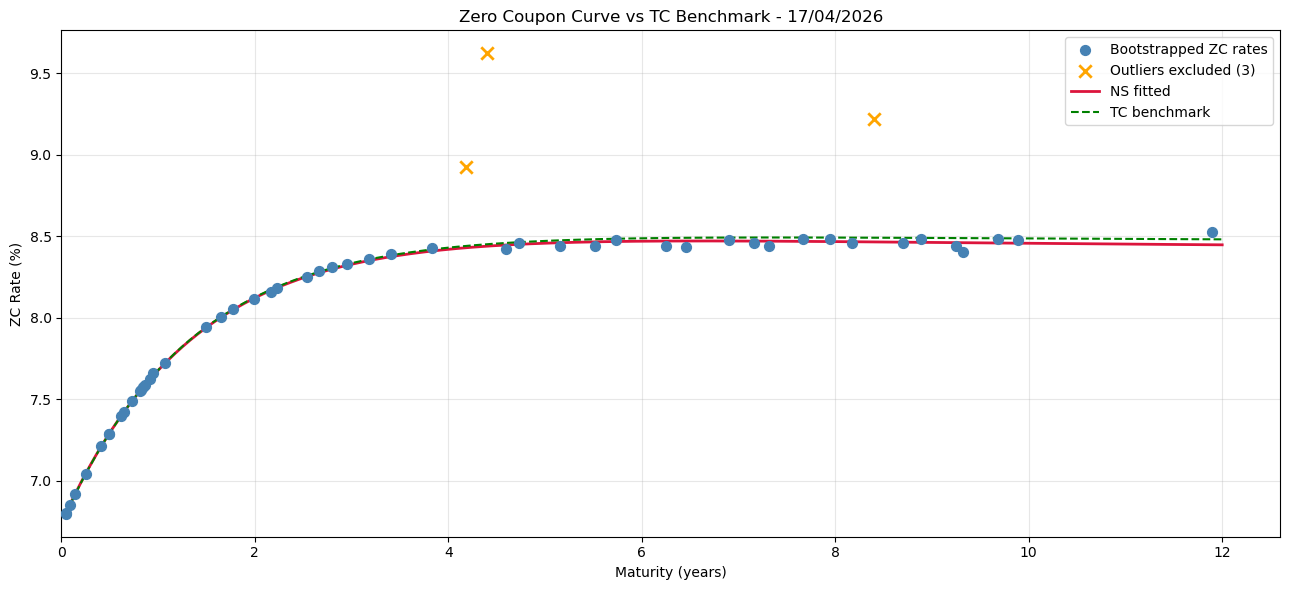

In [27]:
import matplotlib.pyplot as plt

tau_grid  = np.linspace(0.05, 12, 300)
ns_fitted = ns_curve(tau_grid, beta0, beta1, beta2, lam)
tc_fitted = ns_curve(tau_grid, TC_BETA0, TC_BETA1, TC_BETA2, TC_LAMBDA)

plt.figure(figsize=(13, 6))

plt.scatter(zc_mat_clean, zc_rates_clean * 100,
            color='steelblue', s=50, zorder=5,
            label='Bootstrapped ZC rates')
plt.scatter(zc_maturities[outlier_mask], zc_rates[outlier_mask] * 100,
            color='orange', s=80, zorder=6, marker='x', linewidths=2,
            label=f'Outliers excluded ({outlier_mask.sum()})')
plt.plot(tau_grid, ns_fitted * 100,
         color='crimson', linewidth=2,
         label=f'NS fitted')
plt.plot(tau_grid, tc_fitted * 100,
         color='green', linewidth=1.5, linestyle='--',
         label=f'TC benchmark')

plt.xlim(left=0)
plt.xlabel('Maturity (years)')
plt.ylabel('ZC Rate (%)')
plt.title(f'Zero Coupon Curve vs TC Benchmark - 17/04/2026')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()